# Flower Image Classification with Transfer Learning (Keras)

The goal of this project is a model that classifies flowers into categories based on photos.

## Approach

This is implemented using **transfer learning**: a network pre-trained on ImageNet (**MobileNetV2**) serves as the foundation. Its weights are frozen, and only a new classification head is trained on the flower dataset.

## Data

The data source is the TensorFlow dataset **`flower_photos`** with five classes. The data is split reproducibly into training and validation subsets (fixed seed) to ensure a non-overlapping and therefore meaningful evaluation.

## Evaluation

Model performance is assessed using:

- Validation accuracy
- Training and loss curves
- Confusion matrix

## Note

> The concept was developed with the support of Claude; all code was evaluated, reviewed, and adapted by me.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np

### Data Initialization & Data Format

In [9]:
img_size = (160, 160)   # target size every image is resized to
bat_size = 32           # number of images per batch
rounds = 8              # number of training epochs
SEED = 42               # fixed seed for a reproducible train/validation split

data_url = ("https://storage.googleapis.com/download.tensorflow.org/"
            "example_images/flower_photos.tgz")
data_dir = keras.utils.get_file(
    origin=data_url,        # download the archive from this URL
    fname="flower_photos",  # local name for the downloaded data
    untar=True,             # automatically unpack the .tgz archive
)

# get_file can leave the images inside a nested "flower_photos" folder;
# step one level deeper so the five class subfolders are found correctly.
import pathlib
data_dir = pathlib.Path(data_dir)
if (data_dir / "flower_photos").is_dir():
    data_dir = data_dir / "flower_photos"
print("Data:", data_dir)

Data: C:\Users\Admin\.keras\datasets\flower_photos\flower_photos


### Validation and Training Split

In [10]:
train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=img_size,
    batch_size=bat_size,
    label_mode="int",
)
val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=img_size,
    batch_size=bat_size,
    label_mode="int",
)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Performance: prefetch data in the background for lower latency
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Create Model for Transfer Learning

In [11]:
# --- Data augmentation: randomly varies each training image to reduce overfitting ---
data_augmentation = keras.Sequential([   # stack several augmentation layers into one block
    layers.RandomFlip("horizontal"),     # randomly mirror the image left-right
    layers.RandomRotation(0.1),          # randomly rotate by up to ~10% of a full turn
    layers.RandomZoom(0.1),              # randomly zoom in/out by up to 10%
], name="augmentation")                  # name the block (shown in model.summary())

# --- Load the pre-trained MobileNetV2 as the frozen feature extractor ---
base_model = keras.applications.MobileNetV2(
    input_shape=img_size + (3,),  # expected input shape: (160, 160, 3) -> height, width, RGB
    include_top=False,            # drop MobileNetV2's original 1000-class head; we add our own
    weights="imagenet",           # load weights pre-trained on ImageNet (its learned "vision")
)
base_model.trainable = False      # freeze the base: its weights stay unchanged during training

# --- Assemble the full model by chaining the layers (functional API) ---
inputs = keras.Input(shape=img_size + (3,))               # entry point: one image of shape (160, 160, 3)
x = data_augmentation(inputs)                             # apply the random augmentation first
x = keras.applications.mobilenet_v2.preprocess_input(x)   # rescale pixels from [0, 255] to [-1, 1] as MobileNetV2 expects
x = base_model(x, training=False)                         # run through the frozen base -> feature map
x = layers.GlobalAveragePooling2D()(x)                    # collapse the feature map into a single vector
x = layers.Dropout(0.2)(x)                                # randomly drop 20% of the values during training (anti-overfitting)
outputs = layers.Dense(num_classes)(x)                    # new head: one raw output (logit) per class
model = keras.Model(inputs, outputs)                      # bundle input -> output into one trainable model
model.summary()                                           # print an overview of all layers

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compiling & Training

In [12]:
# --- Compile: configure how the model learns ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),               # Adam optimizer with a step size of 0.001
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), # loss for integer labels; from_logits=True because the head has no softmax
    metrics=["accuracy"],                                              # track classification accuracy during training
)

# --- Train: fit the new head to the flower data ---
history = model.fit(
    train_ds,                 # training data (the 80% split)
    validation_data=val_ds,   # validation data (the 20% split), evaluated after every epoch
    epochs=rounds,            # number of full passes over the training data (8)
)                             # history stores the accuracy/loss values per epoch

Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.6431 - loss: 0.9213 - val_accuracy: 0.7997 - val_loss: 0.5339
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.8334 - loss: 0.4741 - val_accuracy: 0.8447 - val_loss: 0.4393
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.8624 - loss: 0.3807 - val_accuracy: 0.8420 - val_loss: 0.4502
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.8736 - loss: 0.3499 - val_accuracy: 0.8569 - val_loss: 0.3928
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.8842 - loss: 0.3249 - val_accuracy: 0.8542 - val_loss: 0.4228
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.8954 - loss: 0.2875 - val_accuracy: 0.8733 - val_loss: 0.3835
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.8982 - loss: 0.2775 - val_accuracy: 0.8665 - val_loss: 0.3786
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.9094 - loss: 0.2501 - val_accuracy: 0.

### Training Curves & Confusion Matrix

Saved: training_curves.png
Saved: confusion_matrix.png


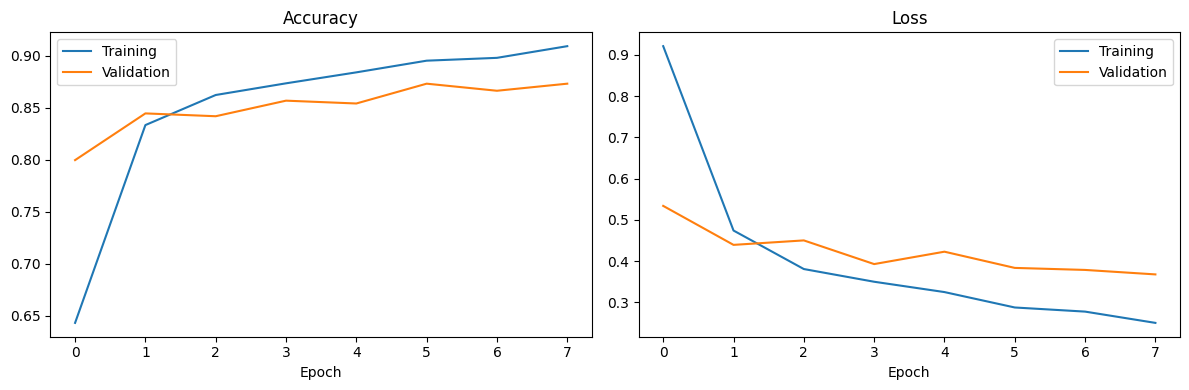

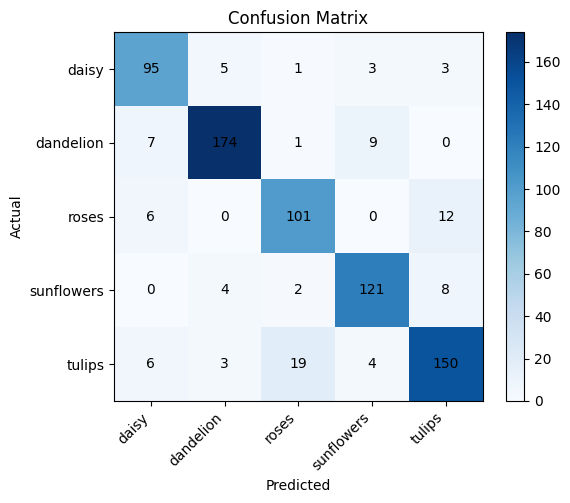

In [13]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training")
plt.plot(epochs_range, val_acc, label="Validation")
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training")
plt.plot(epochs_range, val_loss, label="Validation")
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
print("Saved: training_curves.png")


# Confusion matrix: compare the true labels with the model's predictions on the validation set
y_true, y_pred = [], []
for images, labels in val_ds:
    logits = model.predict(images, verbose=0)
    preds = np.argmax(logits, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

conf_matrix = tf.math.confusion_matrix(y_true, y_pred).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
# write the counts into the cells
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("Saved: confusion_matrix.png")

### Example

In [14]:
model.save("flower_model.keras")
print("Model saved: flower_model.keras")

# Predict a single image from the validation set
for images, labels in val_ds.take(1):
    single_image = images[0]
    logits = model.predict(single_image[tf.newaxis, ...], verbose=0)
    probs = tf.nn.softmax(logits[0])        # logits -> probabilities
    pred_class = class_names[np.argmax(probs)]
    confidence = 100 * np.max(probs)
    print(f"Prediction: {pred_class} ({confidence:.1f}% confident) | "
          f"Actual: {class_names[labels[0]]}")
    break

Model saved: flower_model.keras
Prediction: sunflowers (98.3% confident) | Actual: sunflowers
